# Analysis of experienced plans of Rust QSim vs. Java QSim
Compare in particular car legs of the experienced plans with each other. When I had a first look, it looked like the car travel times vary a lot. This notebook should help to quantify this effect.

In [81]:
%config InlineBackend.figure_format = 'retina'
import pandas as pd

In [82]:
# 20260212 is 1pct
# 20260213 is 10pct

pct = 10

if pct == 10:
    folder = "20260213"
elif pct == 1:
    folder = "20260212"

df_java_legs = pd.read_csv("/Users/paulh/Documents/run-archive/" + folder + "/output/base_legs.csv")
df_java_acts = pd.read_csv("/Users/paulh/Documents/run-archive/" + folder + "/output/base_activities.csv")

df_rust_legs = pd.read_csv("/Users/paulh/Documents/run-archive/" + folder + "/output/rust_legs.csv")
df_rust_acts = pd.read_csv("/Users/paulh/Documents/run-archive/" + folder + "/output/rust_activities.csv")

In [83]:
# join rust legs with java legs based on column "person_id" and "index". if there are personIds present in java but not in rust, filter them out
df_merged_legs = pd.merge(df_java_legs, df_rust_legs, on=["personId", "index"], suffixes=("_java", "_rust"))

df_merged_legs["travel_time_diff"] = df_merged_legs["baseTravelTime_rust"] - df_merged_legs["baseTravelTime_java"]
df_merged_legs["start_time_diff"] = df_merged_legs["startTime_rust"] - df_merged_legs["startTime_java"]

In [84]:
# Do some data checks:
# check that mode_rust und mode_java are the same for all rows
assert (df_merged_legs["mode_java"] == df_merged_legs["mode_rust"]).all(), "Mode mismatch between Java and Rust legs"

# show all rows where travel_time_diff is not 0 for rows with mode_rust = "walk" or "bike" or "ride"
mismatch_teleported = df_merged_legs[
    (df_merged_legs["mode_rust"].isin(["walk", "bike", "ride"])) & (df_merged_legs["travel_time_diff"] != 0)]
print(mismatch_teleported)

# assert that travel_time_diff is -1 for all mismatch_walk_bike
assert (mismatch_teleported["travel_time_diff"] == -1).all(), "Travel time difference for walk/bike/ride legs is not -1"

                             personId  index mode_java routingMode_java  \
121                       bb_000d2248     17      walk              car   
122                       bb_000d2248     19      walk              car   
133                       bb_000d3b9b     17      walk              car   
134                       bb_000d3b9b     19      walk              car   
195                       bb_0013d5f8     17      walk              car   
...                               ...    ...       ...              ...   
3078588  goodsTraffic_re_vkz.1953_4_3     11      walk            truck   
3078597  goodsTraffic_re_vkz.1953_5_0     17      walk            truck   
3078598  goodsTraffic_re_vkz.1953_5_0     19      walk            truck   
3078603  goodsTraffic_re_vkz.1953_5_1      5      walk              car   
3078604  goodsTraffic_re_vkz.1953_5_1      7      walk              car   

         startTime_java  baseTravelTime_java mode_rust routingMode_rust  \
121             58755.0 

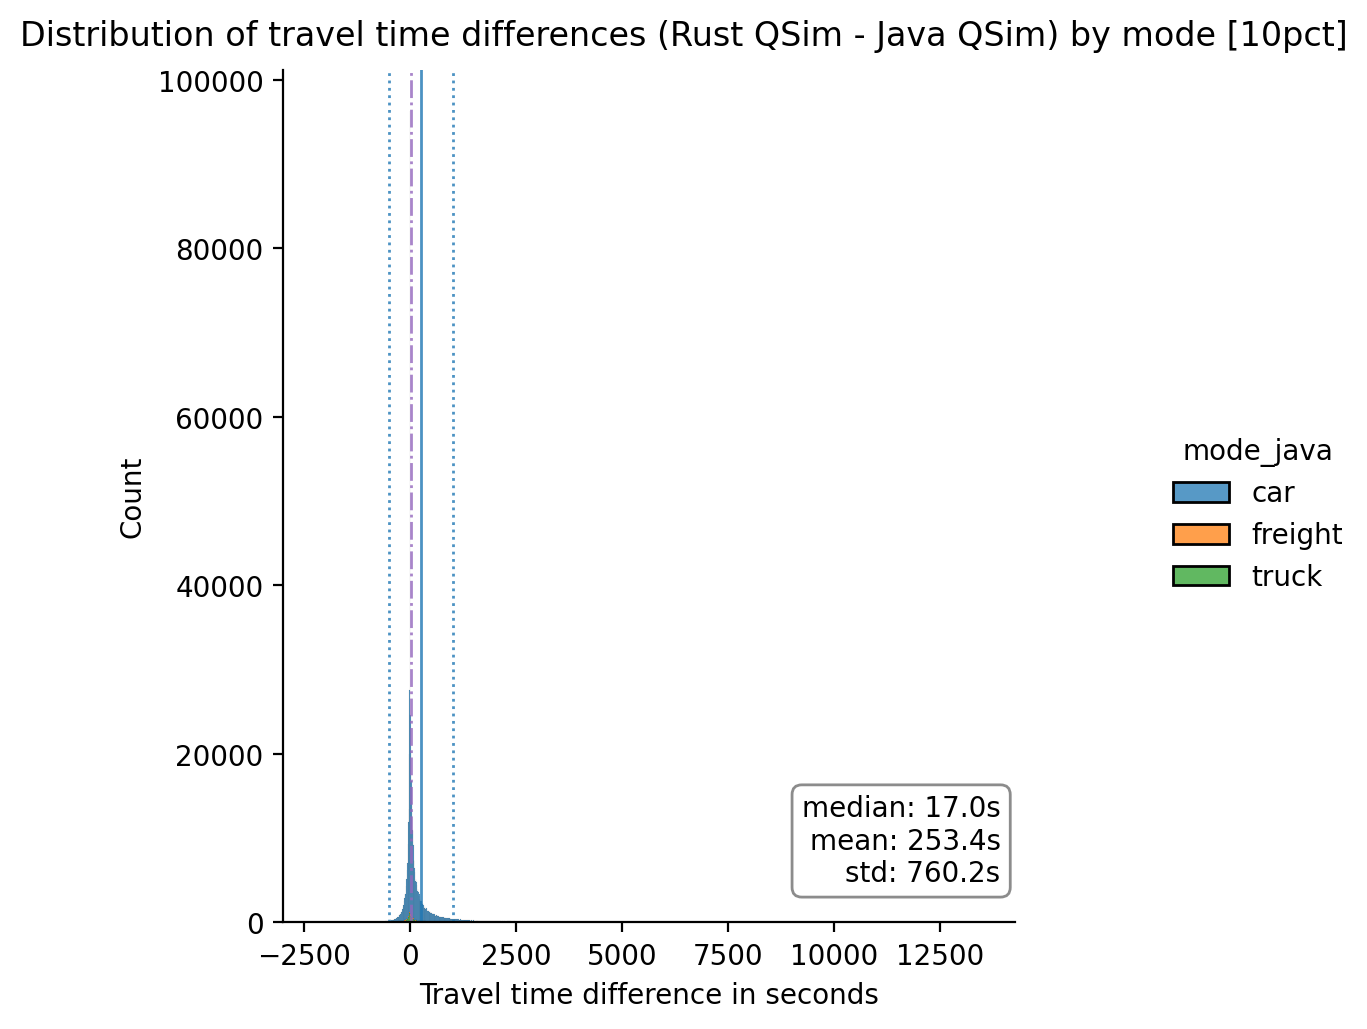

In [85]:
# plot distribution of travel_time_diff. hue by mode_java. exclude walk and bike legs first.
df_network_modes = df_merged_legs[~df_merged_legs["mode_java"].isin(["walk", "bike", "ride"])]

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.displot(data=df_network_modes, x="travel_time_diff", hue="mode_java", multiple="stack")
g.figure.suptitle(
    "Distribution of travel time differences (Rust QSim - Java QSim) by mode [" + str(pct) + "pct]",
    y=1.02,
)
# plt.xscale("symlog", linthresh=10)
g.set_axis_labels("Travel time difference in seconds", "Count")

# summary stats + vertical lines (overall, across all shown modes)
x = df_network_modes["travel_time_diff"].dropna()
mean_ = float(x.mean())
median_ = float(x.median())
std_ = float(x.std())

for ax in g.axes.flat:
    ax.axvline(mean_, color="tab:blue", linestyle="-", linewidth=1., alpha=0.8)
    ax.axvline(median_, color="tab:purple", linestyle="-.", linewidth=1., alpha=0.8)
    ax.axvline(mean_ - std_, color="tab:blue", linestyle=":", linewidth=1., alpha=0.8)
    ax.axvline(mean_ + std_, color="tab:blue", linestyle=":", linewidth=1., alpha=0.8)

    stats_text = (
        f"median: {median_:.1f}s\n"
        f"mean: {mean_:.1f}s\n"
        f"std: {std_:.1f}s"
    )
    ax.text(
        0.98,
        0.15,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.5", alpha=0.9),
    )


In [86]:
# plot startTime_rust on x-axis and start_time_diff on y-axis. hue by mode_java.
# sns.scatterplot(data=df_network_modes, x="startTime_rust", y="start_time_diff", hue="mode_java", alpha=0.5)
# plt.title("Start time difference (Rust QSim - Java QSim) over the day by mode [" + str(pct) + "pct]")
# plt.xlabel("Start time in Rust QSim (seconds since midnight)")
# plt.ylabel("Start time difference in seconds")

N: 534405
min: -2215.0s
p01: -416.0s
median: 17.0s
p99: 3892.0s
max: 13483.0s
mean: 253.4s
std: 760.2s


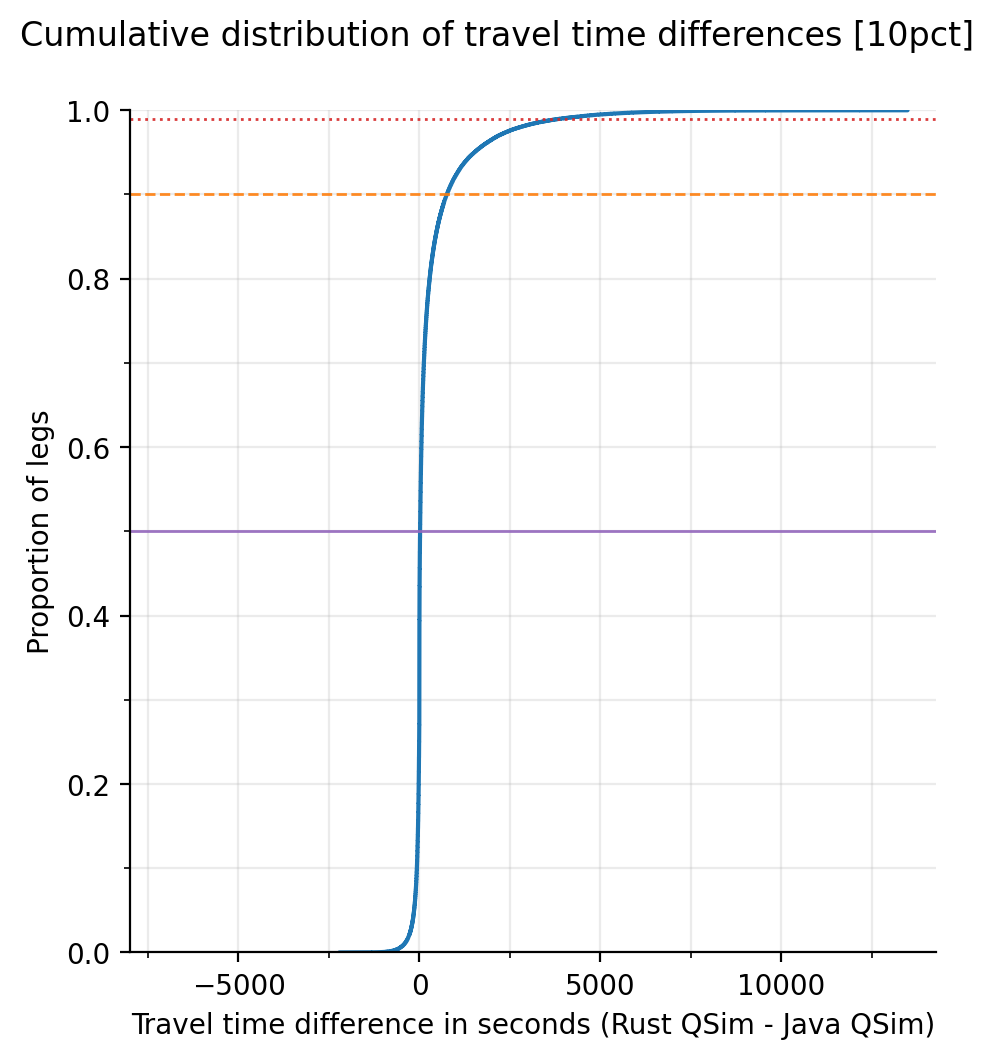

In [87]:
import matplotlib

# plot cumulative distribution function (CDF) of travel_time_diff (all shown network modes)
g = sns.displot(
    data=df_network_modes,
    x="travel_time_diff",
    kind="ecdf",
    stat="proportion",
)

g.set_axis_labels("Travel time difference in seconds (Rust QSim - Java QSim)", "Proportion of legs")
g.figure.suptitle("Cumulative distribution of travel time differences [" + str(pct) + "pct]", y=1.05)

# stats (overall)
x = df_network_modes["travel_time_diff"].dropna()

n_ = int(x.shape[0])
min_ = float(x.min())
p01_ = float(x.quantile(0.01))
median_ = float(x.median())
p99_ = float(x.quantile(0.99))
max_ = float(x.max())
mean_ = float(x.mean())
std_ = float(x.std())

stats_text = (
    f"N: {n_}\n"
    f"min: {min_:.1f}s\n"
    f"p01: {p01_:.1f}s\n"
    f"median: {median_:.1f}s\n"
    f"p99: {p99_:.1f}s\n"
    f"max: {max_:.1f}s\n"
    f"mean: {mean_:.1f}s\n"
    f"std: {std_:.1f}s"
)
print(stats_text)

# horizontal lines + gridlines (small alpha)
for ax in g.axes.flat:
    ax.set_xlim(left=-8000)
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5000))
    # ax.minorticks_on()
    ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    ax.grid(True, which="both", axis="both", alpha=0.25)
    ax.axhline(0.50, color="tab:purple", linestyle="-", linewidth=1., alpha=0.9)
    ax.axhline(0.90, color="tab:orange", linestyle="--", linewidth=1., alpha=0.9)
    ax.axhline(0.99, color="tab:red", linestyle=":", linewidth=1., alpha=0.9)


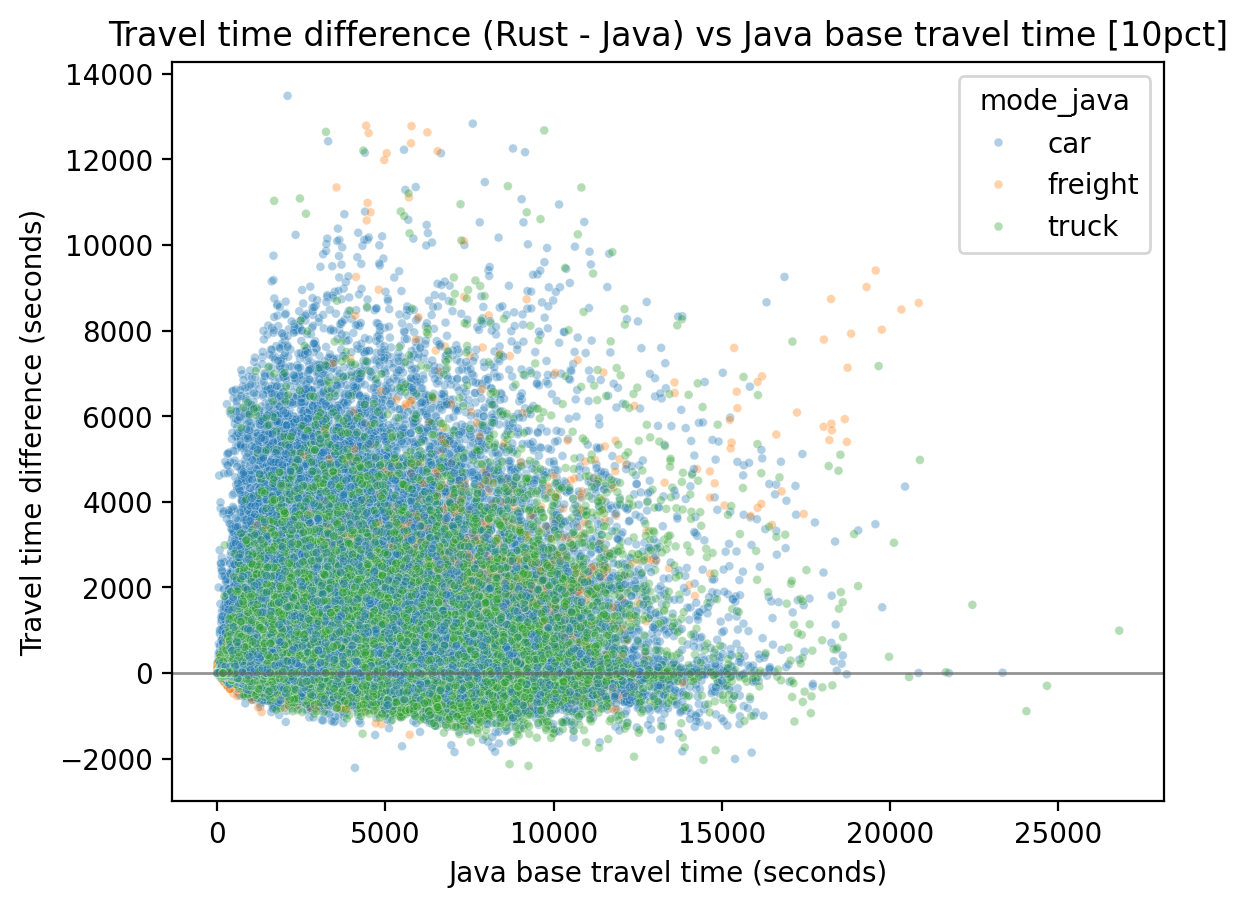

In [88]:
# Scatter: x = baseTravelTime_java, y = travel_time_diff
sns.scatterplot(
    data=df_network_modes,
    x="baseTravelTime_java",
    y="travel_time_diff",
    hue="mode_java",
    alpha=0.35,
    s=10,
)
plt.title("Travel time difference (Rust - Java) vs Java base travel time [" + str(pct) + "pct]")
plt.xlabel("Java base travel time (seconds)")
plt.ylabel("Travel time difference (seconds)")
plt.axhline(0, color="0.4", linewidth=1, alpha=0.7)


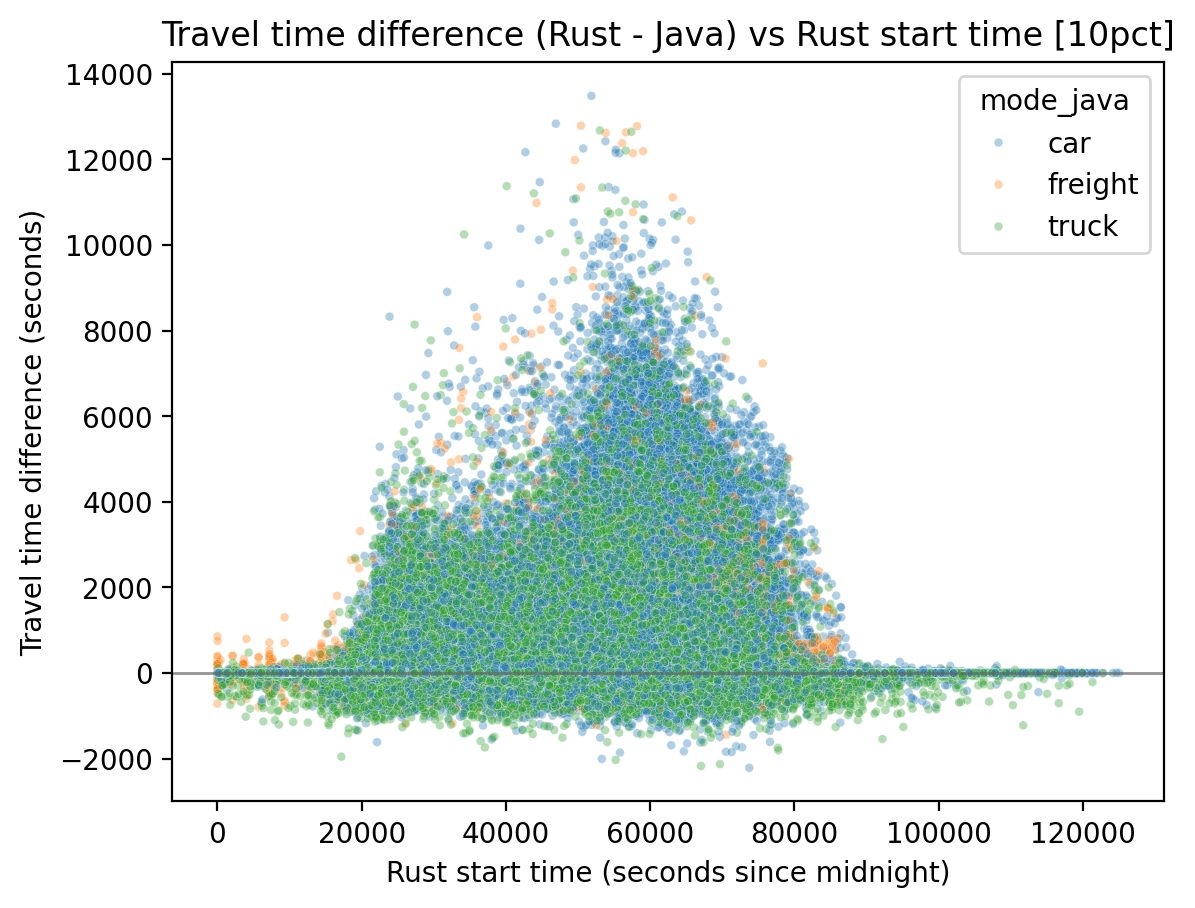

In [89]:
# Scatter: x = startTime_rust, y = travel_time_diff
sns.scatterplot(
    data=df_network_modes,
    x="startTime_rust",
    y="travel_time_diff",
    hue="mode_java",
    alpha=0.35,
    s=10,
)
plt.title("Travel time difference (Rust - Java) vs Rust start time [" + str(pct) + "pct]")
plt.xlabel("Rust start time (seconds since midnight)")
plt.ylabel("Travel time difference (seconds)")
plt.axhline(0, color="0.4", linewidth=1, alpha=0.7)
